# 实验3 机器学习回归与sklearn使用

## 1. sklearn安装 

使用%pip魔法命令，运行以下命令安装sklearn。

In [1]:
%pip install scikit-learn

Looking in indexes: https://mirrors.zju.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. scikit-learn基本用法

参考资料：https://scikit-learn.org/stable/index.html

首先，我们随机生成一组自变量 x的数据，并在此基础上通过添加随机噪声来构建 y。这样，我们可以模拟实际情况中可能存在的测量误差或其他干扰因素，以便拟合模型$y=3x+2$。

通过这种方法，我们旨在评估回归模型在面对真实数据时的表现和预测能力。

（1）数据生成与预处理

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
np.random.seed(0)
X = 2 * np.random.rand(100, 1)  # 生成100个随机点
y = 3 * X.flatten() + 2 + np.random.randn(100) * 0.5  # y = 3x + 2 加入噪声

# 将数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

（2）模型训练

In [3]:
from sklearn.linear_model import LinearRegression
# 创建线性回归模型
model = LinearRegression()
# 训练模型
model.fit(X_train, y_train)

LinearRegression()

（3）模型预测

In [4]:
# 进行预测
y_pred = model.predict(X_test)

（4）模型评估：

使用测试集评估模型的性能，比如计算均方误差（MSE）或决定系数（R²）。

In [5]:
from sklearn.metrics import mean_squared_error, r2_score
# 计算性能指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

（5）可视化

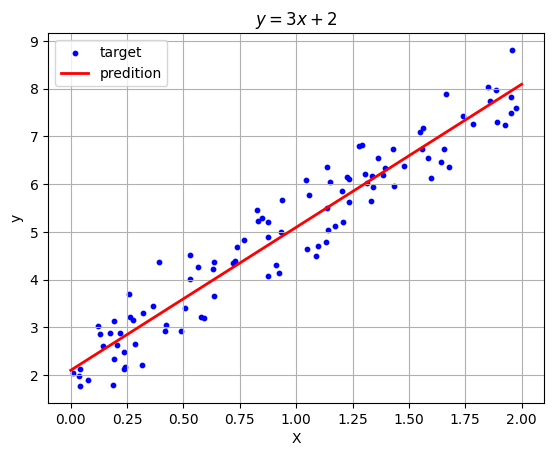

In [6]:
import matplotlib.pyplot as plt
# 原始数据与预测值的可视化
plt.scatter(X, y, color='blue', label='target', s=10)
X_line = np.linspace(0, 2, 100).reshape(-1, 1)  # 创建用于绘制回归线的X值
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=2, label='predition')
plt.xlabel('X')
plt.ylabel('y')
plt.title("$y = 3x + 2$")
plt.legend()
plt.grid()

## 3. 波士顿房价预测实例

本实验将使用波士顿房价数据集。该数据集包含不同特征（如房间数、房龄、距离市中心的距离等）以及相应的房价信息。目标是构建一个模型来预测房价。

（1）数据加载与探索

使用 scikit-learn 提供的工具加载数据，并进行初步探索。

In [7]:
from sklearn.datasets import load_boston
import pandas as pd

# 加载数据集
boston = load_boston()
X = pd.DataFrame(boston.data, columns=boston.feature_names)
y = boston.target

# 数据概览
print(X.head())
print(y[:5])

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  
[24.  21.6 34.7 33.4 36.2]


d:\Other Program Files\Python\AIBasic\Lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California housi

（2）数据预处理

在数据预处理阶段，检查数据的基本信息、缺失值，并决定是否填充或删除这些值（波士顿房价数据集中通常没有缺失值），并将数据分为训练集和测试集，使用80%的数据用于训练，20%用于测试：

In [8]:
from sklearn.model_selection import train_test_split

# 检查缺失值
print(X.isnull().sum())

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64


（3）模型训练

创建线性回归模型，并用训练数据进行拟合

In [9]:
from sklearn.linear_model import LinearRegression

# 创建模型
model = LinearRegression()

# 训练模型
model.fit(X_train, y_train)

LinearRegression()

（4）模型评估

在模型评估阶段，对测试集进行预测，并计算模型性能指标（如均方误差MSE和决定系数R²）：

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

# 进行预测
y_pred = model.predict(X_test)

# 计算性能指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印性能指标
print(f'均方误差 (MSE): {mse}')
print(f'决定系数 (R^2): {r2}')

均方误差 (MSE): 24.29111947497386
决定系数 (R^2): 0.6687594935356274


（5）可视化结果：

通过绘制真实值与预测值的散点图，直观展示模型的拟合效果：

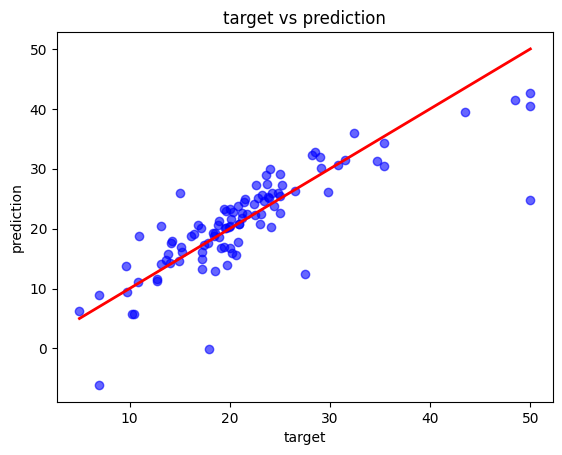

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.xlabel('target')
plt.ylabel('prediction')
plt.title('target vs prediction')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # 理想预测线
plt.show()

## 4. 乳腺癌检测实例

在本案例中，我们将使用经典的乳腺癌数据集（Breast Cancer Dataset）进行乳腺癌检测预测。该数据集包含569个样本，每个样本有30个特征，并标记为良性（0）或恶性（1）。我们的目标是使用这些特征训练一个逻辑回归模型，预测新的样本是良性还是恶性。

（1）数据加载与探索

使用 scikit-learn 提供的工具加载数据，并进行初步探索。

In [12]:
from sklearn import datasets
import pandas as pd

# 加载数据集
cancer = datasets.load_breast_cancer()
X = cancer.data  # 特征数据
y = cancer.target  # 标签数据（0: 良性, 1: 恶性）

# 转换为 DataFrame 以便于探索
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y

#查看数据集的前五行及对应标签
print(df.head())
print(y[:5])

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

（2）数据预处理

在数据预处理阶段，检查数据的基本信息、缺失值，并决定是否填充或删除这些值（乳腺癌数据集中通常没有缺失值），并将数据分为训练集和测试集，使用80%的数据用于训练20%用于测试：

In [13]:
from sklearn.model_selection import train_test_split

# 查看数据集基本信息
print(df.info())

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

（3）模型训练

使用逻辑回归模型进行训练，设置最大迭代次数以确保收敛。

In [14]:
from sklearn.linear_model import LogisticRegression

# 创建模型
model = LogisticRegression(max_iter=10000) # 设置最大迭代次数 

# 训练模型
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

（4）模型评估

在模型评估阶段，对测试集进行预测，并计算模型的准确率，输出混淆矩阵，了解分类效果。

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 进行预测
y_pred = model.predict(X_test)

# 计算性能指标
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

# 打印性能指标
print(f'准确率: {accuracy:.2f}')
print('混淆矩阵:\n', confusion)

准确率: 0.96
混淆矩阵:
 [[39  4]
 [ 1 70]]


（5）可视化结果

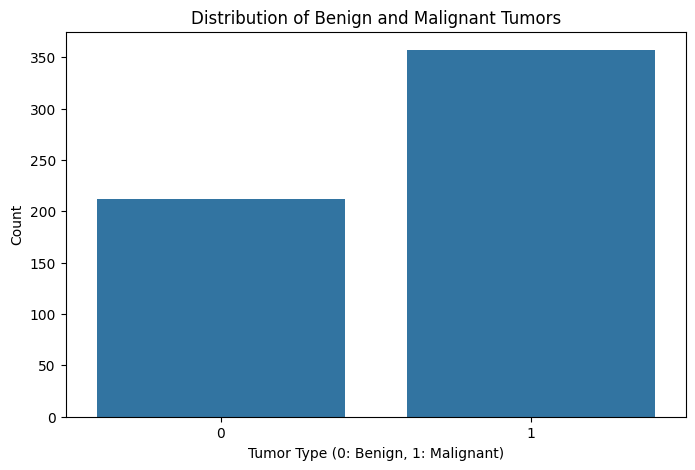

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df)
plt.title('Distribution of Benign and Malignant Tumors')
plt.xlabel('Tumor Type (0: Benign, 1: Malignant)')
plt.ylabel('Count')
plt.show()